# Question-Answer Generation

This notebook trains a sequence-to-sequence model to generate questions from documents using:

- **Bidirectional GRU encoder** with attention mechanism  
- **GRU decoder** for question generation
- **GloVe embeddings** for word representations

Based on the approach from "Generative Deep Learning" (1st Edition, 2019).

---

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# GPU SETUP
# ═══════════════════════════════════════════════════════════════════════════════
# Enable GPU memory growth to prevent TensorFlow from allocating all VRAM at once.
# This allows running multiple notebooks or processes that use GPU.

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU(s) available: {[gpu.name for gpu in gpus]}")
    except RuntimeError as e:
        print(f"GPU setup error: {e}")
else:
    print("⚠ No GPU detected, running on CPU")

2026-02-05 19:42:59.266249: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/cataluna84/Workspace/Generative_Deep_Learning/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


✓ GPU(s) available: ['/physical_device:GPU:0']


## Environment Setup

Import required libraries and configure paths.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS
# ═══════════════════════════════════════════════════════════════════════════════

# Standard library
import os
import sys
import re
import pickle as pkl
import random

# Path setup for utilities
sys.path.insert(0, '..')       # For v1/src modules
sys.path.insert(0, '../..')    # For project root utils/

# Third-party
import numpy as np
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt

# TensorFlow/Keras
import keras.ops as ops
from keras.layers import Input, Embedding, GRU, Bidirectional, Dense, Lambda
from keras.models import Model, load_model
from keras.preprocessing.sequence import pad_sequences
from keras.optimizers import Adam
from keras.utils import plot_model

# W&B for experiment tracking
import wandb

# Project utilities
from utils.callbacks import LRFinder

# Local modules - QA data processing utilities
from src.utils.write import (
    training_data,      # Generator for training batches
    test_data,          # Generator for test batches
    collapse_documents, # Remove duplicate documents
    expand_answers,     # Expand answer tags to spans
    _read_data,         # Raw CSV reader
    glove,              # Pre-loaded GloVe embeddings
    DEFAULT_BATCH_SIZE,  # Default batch size for reference
    look_up_word,       # Word to token ID
    look_up_token,      # Token ID to word
    START_TOKEN,        # Sequence start token
    END_TOKEN,          # Sequence end token
)

## Data Download and Preparation

This cell runs the data download script which:

1. **Extracts QA Dataset** from `v1/data/qa.tar.xz`
2. **Downloads GloVe Embeddings** from Stanford NLP (~862MB)
3. **Creates Trimmed Embeddings** with ~10,000 vocabulary words

Run this cell once before training to ensure all data files are ready.

In [3]:
import subprocess
import os

# Run the data download script
script_path = os.path.join("..", "data_download_scripts", "download_qa_data.sh")
result = subprocess.run(["bash", script_path], capture_output=True, text=True)

print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


╔═══════════════════════════════════════════════════════╗
║  QA Data Setup for Question-Answering Training       ║
╚═══════════════════════════════════════════════════════╝

STEP 1: Extracting QA Dataset
✓ QA data already extracted
-rw-r--r-- 1 cataluna84 cataluna84 345M Jun  1  2020 /home/cataluna84/Workspace/Generative_Deep_Learning/v1/data/qa/train.csv
-rw-r--r-- 1 cataluna84 cataluna84 19M Feb  4 14:44 /home/cataluna84/Workspace/Generative_Deep_Learning/v1/data/qa_test/my_test.csv

STEP 2: Downloading GloVe Embeddings
✓ GloVe already downloaded
-rw-r--r-- 1 cataluna84 cataluna84 332M Feb  4 16:01 /home/cataluna84/Workspace/Generative_Deep_Learning/v1/data/glove/glove.6B.100d.txt

STEP 3: Creating Trimmed Embeddings
✓ Trimmed embeddings already exist
-rw-r--r-- 1 cataluna84 cataluna84 8.1M Feb  4 16:03 /home/cataluna84/Workspace/Generative_Deep_Learning/v1/data/glove/glove.6B.100d.trimmed.txt

✓ Setup Complete!

You can now run: v1/notebooks/06_02_qa_train.ipynb




## Configuration

Global parameters for training and model architecture.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

# Training parameters
EPOCHS = 2000            # Set to 2000 for full training
LEARNING_RATE = 0.001    # Will be updated by LRFinder
LOSS_WEIGHTS = [1, 1]    # [answer_tags, decoder_outputs]

# Model parameters
GRU_UNITS = 100

# Batch size (adjust based on GPU VRAM)
BATCH_SIZE = 256         # For 8GB VRAM; use 128 for 4GB, 256 for 6GB

# LR Scheduler parameters
LR_PATIENCE = 5          # Epochs before reducing LR
LR_FACTOR = 0.5          # LR reduction factor
MIN_LR = 1e-7            # Minimum learning rate
MIN_DELTA = 0.001        # Minimum improvement to count as progress

# Early Stopping parameters
EARLY_STOP_PATIENCE = 10 # Epochs with no improvement before stopping

# Sequence limits (set dynamically from data)
MAX_DOC_SIZE = None
MAX_ANSWER_SIZE = None
MAX_Q_SIZE = None

# Mode: 'build' creates new model, 'load' loads from checkpoint
MODE = 'build'

## Run Folder Configuration

Each training run gets a unique folder with auto-incrementing experiment ID.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# RUN FOLDER CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

SECTION = 'qa'               # Model type folder
DATASET_RUN_ID = '0001'      # Dataset identifier
DATA_NAME = 'qa'             # Dataset name
EXPERIMENT_RUN_ID = None     # Set to None for auto-increment, or specify e.g., '003'

BASE_RUN_FOLDER = f'../run/{SECTION}/{DATASET_RUN_ID}_{DATA_NAME}'


def get_next_experiment_run_id(base_folder):
    """Determine the next available experiment run ID.
    
    Scans existing folders for 3-digit numeric subdirectories
    and returns the next sequential ID.
    
    Args:
        base_folder: Path to the base run folder.
        
    Returns:
        str: 3-digit experiment run ID (e.g., '001', '002').
    """
    if not os.path.exists(base_folder):
        return '001'
    
    existing_ids = []
    for item in os.listdir(base_folder):
        item_path = os.path.join(base_folder, item)
        if os.path.isdir(item_path) and re.match(r'^\d{3}$', item):
            existing_ids.append(int(item))
    
    if not existing_ids:
        return '001'
    
    return f'{max(existing_ids) + 1:03d}'


# Auto-generate EXPERIMENT_RUN_ID if not specified
if EXPERIMENT_RUN_ID is None:
    EXPERIMENT_RUN_ID = get_next_experiment_run_id(BASE_RUN_FOLDER)
    print(f'✓ Auto-generated EXPERIMENT_RUN_ID: {EXPERIMENT_RUN_ID}')

# Full run folder path (includes experiment run ID)
RUN_FOLDER = f'{BASE_RUN_FOLDER}/{EXPERIMENT_RUN_ID}'

# Create directory structure
os.makedirs(RUN_FOLDER, exist_ok=True)
os.makedirs(os.path.join(RUN_FOLDER, 'viz'), exist_ok=True)
os.makedirs(os.path.join(RUN_FOLDER, 'images'), exist_ok=True)
os.makedirs(os.path.join(RUN_FOLDER, 'weights'), exist_ok=True)

print(f'✓ Run folder: {RUN_FOLDER}')

✓ Auto-generated EXPERIMENT_RUN_ID: 012
✓ Run folder: ../run/qa/0001_qa/012


## Weights & Biases Integration

Initialize W&B for experiment tracking and visualization.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# WEIGHTS & BIASES INITIALIZATION
# ═══════════════════════════════════════════════════════════════════════════════

run = wandb.init(
    project="generative-deep-learning",
    name=f"qa_{DATA_NAME}_{DATASET_RUN_ID}_{EXPERIMENT_RUN_ID}",
    config={
        "model": "QA-Seq2Seq",
        "dataset": DATA_NAME,
        "dataset_run_id": DATASET_RUN_ID,
        "experiment_run_id": EXPERIMENT_RUN_ID,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "gru_units": GRU_UNITS,
        "lr_patience": LR_PATIENCE,
        "lr_factor": LR_FACTOR,
    }
)
print(f"✓ W&B run initialized: {wandb.run.url}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: cataluna84 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ W&B run initialized: https://wandb.ai/cataluna84/generative-deep-learning/runs/f6vzy76d


## Data Loading

Load the QA training and test data generators and inspect batch structure.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ═══════════════════════════════════════════════════════════════════════════════

# Create data generators
training_data_gen = training_data()
test_data_gen = test_data(batch_size=BATCH_SIZE)

# Get first batch to inspect structure and set sequence limits
sample_batch = next(training_data())

print("Sample batch keys:", list(sample_batch.keys()))
print(f"Batch size: {sample_batch['size']}")
print(f"Document tokens shape: {sample_batch['document_tokens'].shape}")
print(f"Answer masks shape: {sample_batch['answer_masks'].shape}")
print(f"Question input tokens shape: {sample_batch['question_input_tokens'].shape}")

Sample batch keys: ['size', 'document_ids', 'document_text', 'document_words', 'document_tokens', 'document_lengths', 'answer_text', 'answer_indices', 'answer_labels', 'answer_masks', 'answer_lengths', 'question_text', 'question_input_tokens', 'question_output_tokens', 'question_lengths']
Batch size: 378
Document tokens shape: (378, 200)
Answer masks shape: (378, 39, 200)
Question input tokens shape: (378, 17)


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# GLOVE EMBEDDINGS
# ═══════════════════════════════════════════════════════════════════════════════
# GloVe embeddings are pre-loaded from src.utils.write at import time.

VOCAB_SIZE = glove.shape[0]
EMBEDDING_DIMENS = glove.shape[1]

print(f"✓ GloVe embeddings loaded")
print(f"  Vocabulary size: {VOCAB_SIZE:,}")
print(f"  Embedding dimensions: {EMBEDDING_DIMENS}")

✓ GloVe embeddings loaded
  Vocabulary size: 9,892
  Embedding dimensions: 100


## Model Parameters

Set sequence length parameters based on data dimensions.

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# SEQUENCE LENGTH PARAMETERS
# ═══════════════════════════════════════════════════════════════════════════════
# These are set dynamically based on the data.
# MAX_DOC_SIZE: Maximum document length (tokens)
# MAX_ANSWER_SIZE: Maximum answer span length
# MAX_Q_SIZE: Maximum question length (tokens)

MAX_DOC_SIZE = None      # Will be set from batch shape
MAX_ANSWER_SIZE = None   # Will be set from batch shape
MAX_Q_SIZE = None        # Will be set from batch shape

## Model Architecture

The QA model consists of:
1. **Shared Embedding Layer**: GloVe word embeddings
2. **Answer Tagger**: Bidirectional GRU that identifies answer spans
3. **Encoder**: GRU that encodes the answer context
4. **Decoder**: GRU that generates questions conditioned on the encoder state

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODEL ARCHITECTURE
# ═══════════════════════════════════════════════════════════════════════════════

# Input: Document tokens
document_tokens = Input(shape=(MAX_DOC_SIZE,), name="document_tokens")

# Shared embedding layer (frozen GloVe weights)
embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIMENS,
    weights=[glove],
    mask_zero=True,
    name='embedding'
)
document_emb = embedding(document_tokens)

# Answer tagger: Bidirectional GRU to identify answer spans
answer_outputs = Bidirectional(
    GRU(GRU_UNITS, return_sequences=True),
    name='answer_outputs'
)(document_emb)
answer_tags = Dense(2, activation='softmax', name='answer_tags')(answer_outputs)

# Encoder: Compress answer context using attention mask
encoder_input_mask = Input(
    shape=(MAX_ANSWER_SIZE, MAX_DOC_SIZE),
    name="encoder_input_mask"
)

# Batch matrix multiplication: mask @ answer_outputs
# einsum notation: 'ijk,ikl->ijl' performs batched matmul
# Register custom function for model cloning/serialization
import keras
import keras.ops as ops

@keras.saving.register_keras_serializable(package="QA")
def batch_matmul(inputs):
    """Perform batch matrix multiplication using einsum.
    
    Args:
        inputs: List of [mask, outputs] tensors
        
    Returns:
        Tensor result of batch matrix multiplication
    """
    return ops.einsum('ijk,ikl->ijl', inputs[0], inputs[1])

encoder_inputs = Lambda(
    batch_matmul,
    output_shape=(None, 2 * GRU_UNITS),
    name="encoder_inputs",
)([encoder_input_mask, answer_outputs])

encoder_cell = GRU(2 * GRU_UNITS, name='encoder_cell')(encoder_inputs)

# Decoder: Generate question tokens
decoder_inputs = Input(shape=(MAX_Q_SIZE,), name="decoder_inputs")
decoder_emb = embedding(decoder_inputs)
decoder_emb.trainable = False  # Freeze embedding for decoder

decoder_cell = GRU(2 * GRU_UNITS, return_sequences=True, name='decoder_cell')
decoder_states = decoder_cell(decoder_emb, initial_state=[encoder_cell])

# Output projection
decoder_projection = Dense(
    VOCAB_SIZE,
    name='decoder_projection',
    activation='softmax',
    use_bias=False
)
decoder_outputs = decoder_projection(decoder_states)

# Combined training model
total_model = Model(
    [document_tokens, decoder_inputs, encoder_input_mask],
    [answer_tags, decoder_outputs]
)

# Save model architecture diagram
plot_model(
    total_model,
    to_file=os.path.join(RUN_FOLDER, 'viz/model_architecture.png'),
    show_shapes=True,
    show_layer_names=True
)
print("✓ Model architecture saved to viz/model_architecture.png")

I0000 00:00:1770320619.810624   31560 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6094 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/cataluna84/Workspace/Generative_Deep_Learning/.venv/lib/python3.13/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_inputs' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


✓ Model architecture saved to viz/model_architecture.png


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# SUB-MODELS FOR INFERENCE
# ═══════════════════════════════════════════════════════════════════════════════

# Answer model: Document -> Answer tags
answer_model = Model(document_tokens, [answer_tags])

# Encoder state model: Document + Answer mask -> Encoder hidden state
decoder_initial_state_model = Model(
    [document_tokens, encoder_input_mask],
    [encoder_cell]
)

# Print model summary
print("\n" + "=" * 60)
print("TOTAL MODEL SUMMARY")
print("=" * 60)
total_model.summary()


TOTAL MODEL SUMMARY


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ document_tokens     │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 100) │    989,200 │ document_tokens[… │
│ (Embedding)         │                   │            │ decoder_inputs[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ document_tokens[… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_outputs      │ (None, None, 200) │    121,200 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_input_mask  │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_inputs      │ (None, None, 200) │          0 │ encoder_input_ma… │
│ (Lambda)            │                   │            │ answer_outputs[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_cell (GRU)  │ (None, 200)       │    241,200 │ encoder_inputs[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_cell (GRU)  │ (None, None, 200) │    181,200 │ embedding[1][0],  │
│                     │                   │            │ encoder_cell[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_tags (Dense) │ (None, None, 2)   │        402 │ answer_outputs[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_projection  │ (None, None,      │  1,978,400 │ decoder_cell[0][… │
│ (Dense)             │ 9892)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,511,602 (13.40 MB)

 Trainable params: 3,511,602 (13.40 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# INFERENCE MODEL
# ═══════════════════════════════════════════════════════════════════════════════
# Single-step decoder for autoregressive generation at inference time.

decoder_inputs_dynamic = Input(shape=(1,), name="decoder_inputs_dynamic")
decoder_emb_dynamic = embedding(decoder_inputs_dynamic)

# Initial state from encoder
decoder_init_state_dynamic = Input(
    shape=(2 * GRU_UNITS,),
    name='decoder_init_state_dynamic'
)

decoder_states_dynamic = decoder_cell(
    decoder_emb_dynamic,
    initial_state=[decoder_init_state_dynamic]
)
decoder_outputs_dynamic = decoder_projection(decoder_states_dynamic)

# Question generation model (single step)
question_model = Model(
    [decoder_inputs_dynamic, decoder_init_state_dynamic],
    [decoder_outputs_dynamic, decoder_states_dynamic]
)

## Learning Rate Finder

Find optimal learning rate using the LRFinder callback on a cloned model.

/home/cataluna84/Workspace/Generative_Deep_Learning/.venv/lib/python3.13/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_inputs' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Running LRFinder on tf.data.Dataset for 50 steps...


2026-02-05 19:44:05.703787: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 219ms/step - answer_tags_loss: 0.5435 - decoder_projection_loss: 8.3587 - loss: 9.0789
Optimal Learning Rate (Recommended): 0.006651


2026-02-05 19:44:18.057712: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-02-05 19:44:18.057791: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 10214715571340341006
2026-02-05 19:44:18.057807: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 47857316551826920
2026-02-05 19:44:18.057813: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2026-02-05 19:44:18.057884: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 10797601356421710571
2026-02-05 19:44:18.057891: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 8594910032393046717
2026-02-05 

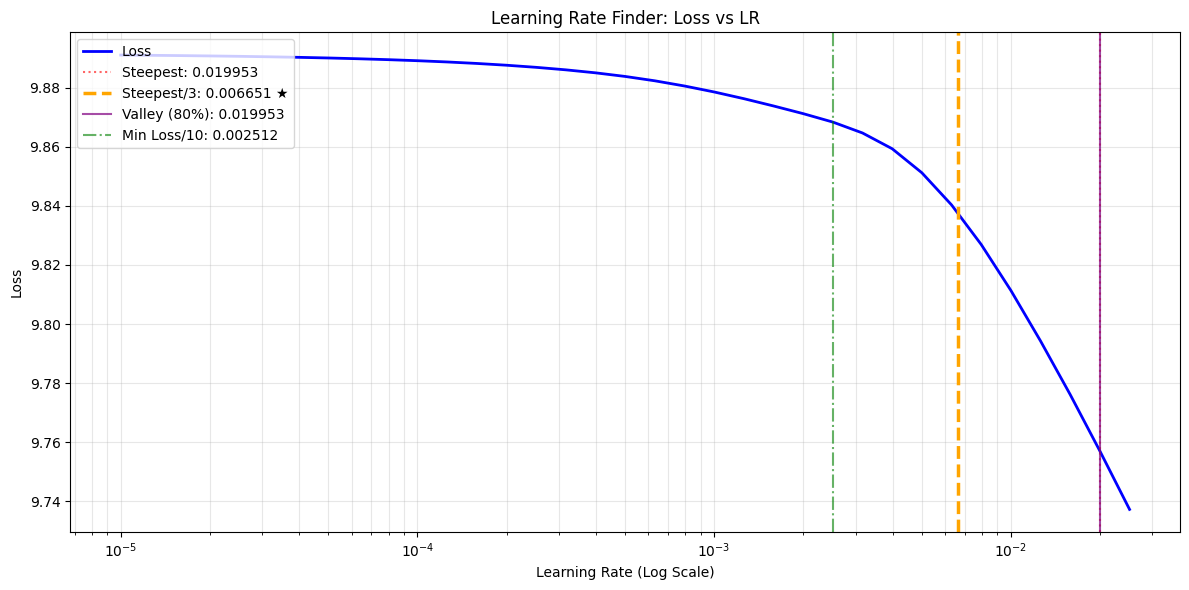

<Figure size 640x480 with 0 Axes>

             LR FINDER RESULTS
  🔴 Steepest Gradient : 0.019953  (aggressive)
  🟠 Steepest / 3      : 0.006651  (balanced) ★ DEFAULT
  🟣 Valley (80%)      : 0.019953  (robust)
  🟢 Min Loss / 10     : 0.002512  (conservative)
  Selected Method: 'recommended' → LR = 0.006651

✓ Optimal learning rate: 6.65e-03


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# LEARNING RATE FINDER
# ═══════════════════════════════════════════════════════════════════════════════
# Run LRFinder on a cloned model to find optimal learning rate.
# We use tf.data.Dataset to handle variable batch shapes robustly.

import tensorflow as tf

# Clone model for LR finding
lr_model = tf.keras.models.clone_model(total_model)
lr_model.compile(
    loss=['sparse_categorical_crossentropy', 'sparse_categorical_crossentropy'],
    optimizer=Adam(learning_rate=1e-6),
    loss_weights=LOSS_WEIGHTS
)

def lr_finder_generator():
    """Yield batches formatted as (inputs, targets) tuples."""
    gen = training_data()
    for batch in gen:
        # Inputs: (document_tokens, split_decoder_inputs, encoder_input_mask)
        # Note: 'split_decoder_inputs' depends on what the model expects. 
        # Looking at model definition:
        # [document_tokens, decoder_inputs, encoder_input_mask]
        
        x = (
            batch['document_tokens'],
            batch['question_input_tokens'],
            batch['answer_masks']
        )
        
        y = (
            np.expand_dims(batch['answer_labels'], axis=-1),
            np.expand_dims(batch['question_output_tokens'], axis=-1)
        )
        yield x, y

# Define output signature for dynamic shapes
# Shapes are used to validate the generator output
# (batch_size, length) -> (None, None)
output_signature = (
    (
        tf.TensorSpec(shape=(None, None), dtype=tf.int32),        # document_tokens
        tf.TensorSpec(shape=(None, None), dtype=tf.int32),        # decoder_inputs
        tf.TensorSpec(shape=(None, None, None), dtype=tf.int32),  # encoder_input_mask
    ),
    (
        tf.TensorSpec(shape=(None, None, 1), dtype=tf.int32),     # answer_tags
        tf.TensorSpec(shape=(None, None, 1), dtype=tf.int32),     # decoder_outputs
    )
)

# Create dataset
# steps_per_epoch is technically optional if repeating, but good for limit
STEPS = 50
dataset = tf.data.Dataset.from_generator(
    lr_finder_generator,
    output_signature=output_signature
).take(STEPS)

print(f"Running LRFinder on tf.data.Dataset for {STEPS} steps...")
lr_finder = LRFinder(min_lr=1e-6, max_lr=1e-1, steps=STEPS)
lr_model.fit(
    dataset,
    epochs=1,
    callbacks=[lr_finder],
    verbose=1
)

# Visualize and get optimal LR
lr_finder.plot_loss()
plt.savefig(os.path.join(RUN_FOLDER, 'viz/lr_finder.png'), dpi=150)
plt.show()

optimal_lr = lr_finder.get_optimal_lr()
print(f"\n✓ Optimal learning rate: {optimal_lr:.2e}")

# Update configuration
LEARNING_RATE = optimal_lr
wandb.config.update({"learning_rate": optimal_lr})

## Model Compilation

Compile the model with optimal learning rate from LRFinder.

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMPILE TRAINING MODEL
# ═══════════════════════════════════════════════════════════════════════════════

optimizer = Adam(learning_rate=LEARNING_RATE)

total_model.compile(
    loss=['sparse_categorical_crossentropy', 'sparse_categorical_crossentropy'],
    optimizer=optimizer,
    loss_weights=LOSS_WEIGHTS
)

print(f"✓ Model compiled with learning rate: {LEARNING_RATE:.2e}")

✓ Model compiled with learning rate: 6.65e-03


## Training Loop

Custom training loop with:
- **Batch processing**: Uses `train_on_batch` for fine-grained control
- **W&B logging**: Logs metrics at end of each epoch
- **ReduceLROnPlateau**: Reduces LR when loss plateaus

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP WITH CALLBACKS
# ═══════════════════════════════════════════════════════════════════════════════

training_loss_history = []
test_loss_history = []

# Starting epoch (for resuming training)
start_epoch = 1

# LR scheduler state
best_loss = float('inf')
no_improve_count = 0
early_stop_count = 0
current_lr = LEARNING_RATE


epoch_pbar = trange(start_epoch, start_epoch + EPOCHS + 1, desc='Training', unit='epoch')

for epoch in epoch_pbar:
    
    epoch_train_loss = []
    epoch_test_loss = []
    
    batch_pbar = tqdm(enumerate(training_data(batch_size=BATCH_SIZE)), desc=f'Epoch {epoch}', leave=False)
    
    for i, batch in batch_pbar:
        # Get validation batch (cycle through test data)
        val_batch = next(test_data_gen, None)
        if val_batch is None:
            test_data_gen = test_data(batch_size=BATCH_SIZE)
            val_batch = next(test_data_gen, None)
        
        # Prepare inputs and targets
        x_train = [
            batch['document_tokens'],
            batch['question_input_tokens'],
            batch['answer_masks']
        ]
        y_train = [
            np.expand_dims(batch['answer_labels'], axis=-1),
            np.expand_dims(batch['question_output_tokens'], axis=-1)
        ]
        
        x_val = [
            val_batch['document_tokens'],
            val_batch['question_input_tokens'],
            val_batch['answer_masks']
        ]
        y_val = [
            np.expand_dims(val_batch['answer_labels'], axis=-1),
            np.expand_dims(val_batch['question_output_tokens'], axis=-1)
        ]
        
        # Training step
        training_loss = total_model.train_on_batch(x_train, y_train)
        test_loss = total_model.test_on_batch(x_val, y_val)
        
        training_loss_history.append(training_loss)
        test_loss_history.append(test_loss)
        epoch_train_loss.append(training_loss[0])
        epoch_test_loss.append(test_loss[0])
        
        # Update batch progress bar
        batch_pbar.set_postfix({
            'train': f'{training_loss[0]:.4f}',
            'test': f'{test_loss[0]:.4f}',
            'lr': f'{current_lr:.2e}'
        })
        
    
    # End of epoch calculations
    avg_train_loss = np.mean(epoch_train_loss)
    avg_test_loss = np.mean(epoch_test_loss)
    
    # W&B logging (replaces WandbMetricsLogger)
    wandb.log({
        "epoch": epoch,
        "train_loss": avg_train_loss,
        "test_loss": avg_test_loss,
        "learning_rate": current_lr,
        "train_answer_loss": np.mean([l[1] for l in training_loss_history[-len(epoch_train_loss):]]),
        "train_decoder_loss": np.mean([l[2] for l in training_loss_history[-len(epoch_train_loss):]]),
    })
    
    # Update epoch progress bar with summary
    epoch_pbar.set_postfix({
        'train': f'{avg_train_loss:.4f}',
        'test': f'{avg_test_loss:.4f}',
        'best': f'{best_loss:.4f}',
        'lr': f'{current_lr:.2e}'
    })
    
    # Log epoch summary for persistent history
    tqdm.write(f"Epoch {epoch:3d} | Train: {avg_train_loss:.4f} | Test: {avg_test_loss:.4f} | Best: {best_loss:.4f} | LR: {current_lr:.2e}")
    
    # ReduceLROnPlateau equivalent with min_delta
    if avg_test_loss < (best_loss - MIN_DELTA):
        best_loss = avg_test_loss
        no_improve_count = 0
        early_stop_count = 0
        # Save best weights
        total_model.save_weights(
            os.path.join(RUN_FOLDER, 'weights/best_weights.weights.h5')
        )
    else:
        no_improve_count += 1
        early_stop_count += 1
        tqdm.write(f"  ⚠ No improvement for {no_improve_count}/{LR_PATIENCE} epochs (LR), {early_stop_count}/{EARLY_STOP_PATIENCE} epochs (ES)")
        if no_improve_count >= LR_PATIENCE and current_lr > MIN_LR:
            current_lr = max(current_lr * LR_FACTOR, MIN_LR)
            total_model.optimizer.learning_rate.assign(current_lr)
            tqdm.write(f"  → Reducing LR to {current_lr:.2e}")
            no_improve_count = 0
    
    # Early Stopping check
    if early_stop_count >= EARLY_STOP_PATIENCE:
        tqdm.write(f"\n✓ Early stopping triggered after {epoch} epochs")
        tqdm.write(f"  Best test loss: {best_loss:.4f}")
        # Load best weights
        total_model.load_weights(
            os.path.join(RUN_FOLDER, 'weights/best_weights.weights.h5')
        )
        break
    
    # Save weights at end of epoch
    total_model.save_weights(
        os.path.join(RUN_FOLDER, f'weights/weights_{epoch:03d}.weights.h5')
    )

tqdm.write("\n" + "=" * 60)
tqdm.write("Training complete!")
tqdm.write("=" * 60)


Training:   0%|          | 0/2001 [00:00<?, ?epoch/s]

Epoch 1: 0it [00:00, ?it/s]

Epoch   1 | Train: 5.3898 | Test: 5.3797 | Best: inf | LR: 6.65e-03


Epoch 2: 0it [00:00, ?it/s]

Epoch   2 | Train: 4.5164 | Test: 4.5158 | Best: 5.3797 | LR: 6.65e-03


...

Epoch  40 | Train: 3.4764 | Test: 3.4765 | Best: 3.4712 | LR: 1.66e-03
  ⚠ No improvement for 3/5 epochs (LR), 8/10 epochs (ES)


Epoch 41: 0it [00:00, ?it/s]

Epoch  41 | Train: 3.4775 | Test: 3.4776 | Best: 3.4712 | LR: 1.66e-03
  ⚠ No improvement for 4/5 epochs (LR), 9/10 epochs (ES)


Epoch 42: 0it [00:00, ?it/s]

Epoch  42 | Train: 3.4789 | Test: 3.4790 | Best: 3.4712 | LR: 1.66e-03
  ⚠ No improvement for 5/5 epochs (LR), 10/10 epochs (ES)
  → Reducing LR to 8.31e-04

✓ Early stopping triggered after 42 epochs
  Best test loss: 3.4712

Training complete!


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# SAVE TRAINING HISTORY
# ═══════════════════════════════════════════════════════════════════════════════

history_path = os.path.join(RUN_FOLDER, 'weights/histories.pkl')
pkl.dump([training_loss_history, test_loss_history], open(history_path, 'wb'))
print(f"✓ Training history saved to {history_path}")

✓ Training history saved to ../run/qa/0001_qa/012/weights/histories.pkl


## Training Visualization

Plot training and test loss curves.

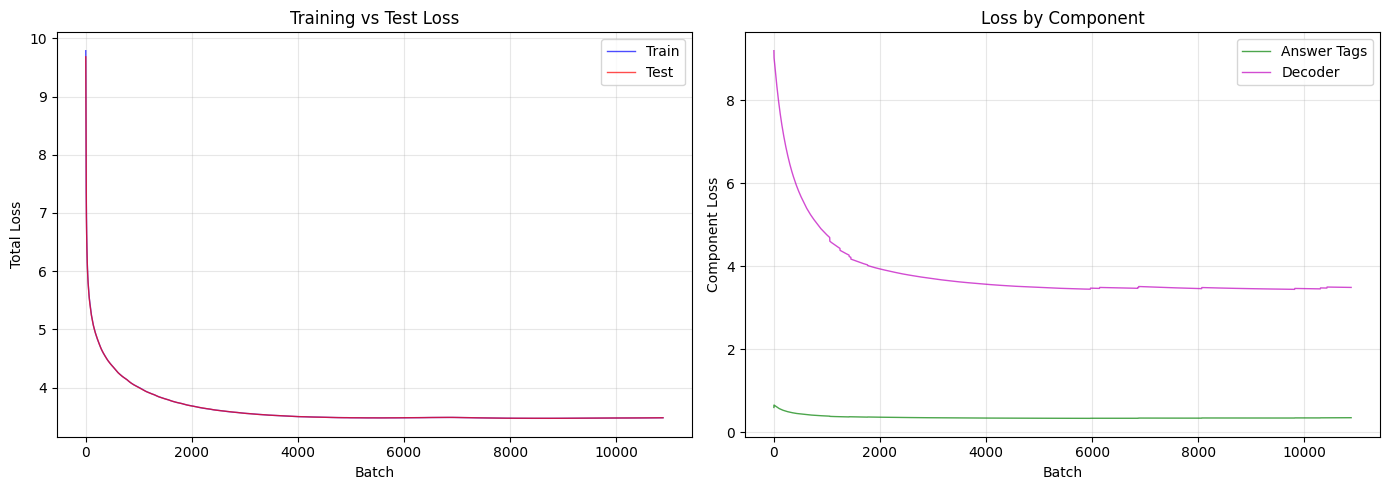

✓ Training visualization saved to ../run/qa/0001_qa/012/viz/training_history.png


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall Loss
train_losses = np.array(training_loss_history)[:, 0]
test_losses = np.array(test_loss_history)[:, 0]

axes[0].plot(train_losses, 'b-', alpha=0.7, label='Train', linewidth=1)
axes[0].plot(test_losses, 'r-', alpha=0.7, label='Test', linewidth=1)
axes[0].set_xlabel('Batch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training vs Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Loss by Component  
axes[1].plot(np.array(training_loss_history)[:, 1], 'g-', alpha=0.7, label='Answer Tags', linewidth=1)
axes[1].plot(np.array(training_loss_history)[:, 2], 'm-', alpha=0.7, label='Decoder', linewidth=1)
axes[1].set_xlabel('Batch')
axes[1].set_ylabel('Component Loss')
axes[1].set_title('Loss by Component')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save and log
viz_path = os.path.join(RUN_FOLDER, 'viz/training_history.png')
plt.savefig(viz_path, dpi=150)
plt.show()

wandb.log({"training_history": wandb.Image(viz_path)})
print(f"✓ Training visualization saved to {viz_path}")

## Save Model and Finalize

Save the trained model and close W&B run.

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# SAVE MODEL AND FINALIZE
# ═══════════════════════════════════════════════════════════════════════════════

# Save model in Keras 3.0+ format
model_path = os.path.join(RUN_FOLDER, 'model.keras')
total_model.save(model_path)
print(f"✓ Model saved to {model_path}")

# Print training summary
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"  Run folder: {RUN_FOLDER}")
print(f"  Epochs trained: {EPOCHS}")
print(f"  Final LR: {current_lr:.2e}")
print(f"  Final Train Loss: {training_loss_history[-1][0]:.4f}")
print(f"  Final Test Loss: {test_loss_history[-1][0]:.4f}")
print(f"  W&B URL: {wandb.run.url}")
print("=" * 60)

# Finish W&B run
wandb.finish()
print("\n✓ W&B run finished")

✓ Model saved to ../run/qa/0001_qa/012/model.keras

TRAINING SUMMARY
  Run folder: ../run/qa/0001_qa/012
  Epochs trained: 2000
  Final LR: 8.31e-04
  Final Train Loss: 3.4800
  Final Test Loss: 3.4801
  W&B URL: https://wandb.ai/cataluna84/generative-deep-learning/runs/f6vzy76d


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
learning_rate,█████████████████████████▃▃▃▃▃▃▃▃▃▃▃▁▁▁▁
test_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_answer_loss,█▅▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_decoder_loss,█▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,42
learning_rate,0.00166
test_loss,3.47903
train_answer_loss,0.34959
train_decoder_loss,3.49117



✓ W&B run finished


## Cleanup

Restart the kernel to release GPU memory.

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# CLEANUP: Restart kernel to fully release GPU memory
# ═══════════════════════════════════════════════════════════════════════════════
# TensorFlow/CUDA does not release GPU memory within a running Python process.
# Restarting the kernel is the only guaranteed way to free all GPU resources.
# 
# Only run this cell after all work is complete and saved.

# import IPython
# print("Restarting kernel to release GPU memory...")
# IPython.Application.instance().kernel.do_shutdown(restart=True)

---

## Master Experiment Log

Track all training runs for this notebook.

| Run | Date | W&B URL | Epochs | LR | Train Loss | Test Loss | Notes |
|-----|------|---------|--------|-----|------------|-----------|-------|
| 001 | | [View]() | 10 | | | | Initial test |
| 006 | 2026-02-04 | [View](https://wandb.ai/cataluna84/generative-deep-learning/runs/bnr3wqpd) | 10 | 6.65e-03 | 3.5806 | 3.5807 | Standardization complete, LRFinder fixed |
| 012 | 2026-02-05 | [View](https://wandb.ai/cataluna84/generative-deep-learning/runs/f6vzy76d) | 42 (ES) | 6.65e-03 → 8.31e-04 | 3.4712 | 3.4712 | Batch=128, early stopping at epoch 42 |
